# **Ancient Greek POS Tagger with MLPs**

### **Assignment 3b - Natural Language Processing - MSc. Computer Science, AUEB [2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

In [ ]:
# Make a data directory
import os
os.makedirs("data", exist_ok=True)

# Download the train/dev/test files
!wget -O data/grc_proiel-ud-train.conllu https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-train.conllu
!wget -O data/grc_proiel-ud-dev.conllu   https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-dev.conllu
!wget -O data/grc_proiel-ud-test.conllu  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-test.conllu

# Verify they’re there
!ls -lh data


--2025-11-24 17:53:42--  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-train.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20765815 (20M) [text/plain]
Saving to: ‘data/grc_proiel-ud-train.conllu’

data/grc_proiel-ud- 100%[===================>]  19.80M   119MB/s    in 0.2s    

2025-11-24 17:53:43 (119 MB/s) - ‘data/grc_proiel-ud-train.conllu’ saved [20765815/20765815]

--2025-11-24 17:53:43--  https://raw.githubusercontent.com/UniversalDependencies/UD_Ancient_Greek-PROIEL/master/grc_proiel-ud-dev.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.1

In [ ]:
def read_conllu(path):
    sentences = []
    words = []
    tags = []

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if words:
                    sentences.append((words, tags))
                    words, tags = [], []
                continue
            if line.startswith("#"):
                continue
            parts = line.split("\t")
            if "-" in parts[0] or "." in parts[0]:
                continue
            word = parts[1]   # FORM
            upos = parts[3]   # UPOS tag
            words.append(word)
            tags.append(upos)

    if words:
        sentences.append((words, tags))

    return sentences

train_path = "data/grc_proiel-ud-train.conllu"
dev_path   = "data/grc_proiel-ud-dev.conllu"
test_path  = "data/grc_proiel-ud-test.conllu"

train_sents = read_conllu(train_path)
dev_sents   = read_conllu(dev_path)
test_sents  = read_conllu(test_path)

print(f"Train sentences: {len(train_sents)}")
print(f"Dev sentences:   {len(dev_sents)}")
print(f"Test sentences:  {len(test_sents)}")
print("Example:", train_sents[0])


Train sentences: 15016
Dev sentences:   1019
Test sentences:  1047
Example: (['Ἡροδότου', 'Ἁλικαρνησσέος', 'ἱστορίης', 'ἀπόδεξις', 'ἥδε', 'ὡς', 'μήτε', 'τὰ', 'γενόμενα', 'ἐξ', 'ἀνθρώπων', 'τῷ', 'χρόνῳ', 'ἐξίτηλα', 'γένηται', 'μήτε', 'ἔργα', 'μεγάλα', 'τε', 'καὶ', 'θωμαστά', 'τὰ', 'μὲν', 'Ἕλλησι', 'τὰ', 'δὲ', 'βαρβάροισι', 'ἀποδεχθέντα', 'ἀκλεᾶ', 'γένηται', 'τά', 'τε', 'ἄλλα', 'καὶ', 'δι’', 'ἣν', 'αἰτίην', 'ἐπολέμησαν', 'ἀλλήλοισι'], ['PROPN', 'NOUN', 'NOUN', 'NOUN', 'PRON', 'SCONJ', 'CCONJ', 'DET', 'VERB', 'ADP', 'NOUN', 'DET', 'NOUN', 'ADJ', 'VERB', 'CCONJ', 'NOUN', 'ADJ', 'CCONJ', 'CCONJ', 'ADJ', 'PRON', 'ADV', 'NOUN', 'PRON', 'ADV', 'NOUN', 'VERB', 'ADJ', 'VERB', 'DET', 'CCONJ', 'PRON', 'CCONJ', 'ADP', 'PRON', 'NOUN', 'VERB', 'PRON'])


In [ ]:
from collections import Counter
import numpy as np

def dataset_stats(sentences):
    # sentences: list of (words, tags)
    num_sents = len(sentences)
    lengths = [len(words) for words, tags in sentences]
    all_words = [w for words, tags in sentences for w in words]
    all_tags  = [t for words, tags in sentences for t in tags]
    vocab = set(all_words)
    tagset = set(all_tags)
    return {
        "num_sents": num_sents,
        "num_tokens": len(all_words),
        "avg_sent_len": float(np.mean(lengths)),
        "median_sent_len": float(np.median(lengths)),
        "vocab_size": len(vocab),
        "num_tags": len(tagset),
        "tag_counts": Counter(all_tags),
    }

for name, sents in [("train", train_sents), ("dev", dev_sents), ("test", test_sents)]:
    stats = dataset_stats(sents)
    print(f"{name.upper()} stats:")
    print(f"  sentences:        {stats['num_sents']}")
    print(f"  tokens:           {stats['num_tokens']}")
    print(f"  avg sent length:  {stats['avg_sent_len']:.2f}")
    print(f"  median sent len:  {stats['median_sent_len']:.2f}")
    print(f"  vocab size:       {stats['vocab_size']}")
    print(f"  number of tags:   {stats['num_tags']}")
    print("  most common tags:")
    for tag, c in stats["tag_counts"].most_common(10):
        print(f"    {tag}: {c}")
    print()


TRAIN stats:
  sentences:        15016
  tokens:           187039
  avg sent length:  12.46
  median sent len:  10.00
  vocab size:       30349
  number of tags:   13
  most common tags:
    VERB: 34517
    NOUN: 31424
    DET: 28070
    ADV: 20288
    PRON: 19756
    ADP: 13812
    CCONJ: 12117
    ADJ: 10361
    PROPN: 7745
    SCONJ: 3610

DEV stats:
  sentences:        1019
  tokens:           13652
  avg sent length:  13.40
  median sent len:  11.00
  vocab size:       4541
  number of tags:   13
  most common tags:
    VERB: 2671
    NOUN: 2185
    DET: 2082
    PRON: 1446
    ADV: 1378
    CCONJ: 978
    ADP: 922
    ADJ: 729
    PROPN: 618
    SCONJ: 257

TEST stats:
  sentences:        1047
  tokens:           13314
  avg sent length:  12.72
  median sent len:  11.00
  vocab size:       4495
  number of tags:   13
  most common tags:
    VERB: 2494
    NOUN: 2209
    DET: 2006
    PRON: 1427
    ADV: 1416
    CCONJ: 1011
    ADP: 885
    ADJ: 752
    PROPN: 494
    AUX: 248



In [ ]:
from collections import Counter
import numpy as np

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def build_word_vocab(sentences, min_freq=1):
    word_counter = Counter(w for words, tags in sentences for w in words)
    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for w, c in word_counter.items():
        if c >= min_freq:
            word2idx[w] = len(word2idx)
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

def build_tag_vocab(sentences):
    tag_set = sorted({t for words, tags in sentences for t in tags})
    tag2idx = {t: i for i, t in enumerate(tag_set)}
    idx2tag = {i: t for t, i in tag2idx.items()}
    return tag2idx, idx2tag

# Build vocabularies
word2idx, idx2word = build_word_vocab(train_sents, min_freq=1)
tag2idx, idx2tag   = build_tag_vocab(train_sents)

print("Vocab size:", len(word2idx))
print("Tags:", tag2idx)

Vocab size: 30351
Tags: {'ADJ': 0, 'ADP': 1, 'ADV': 2, 'AUX': 3, 'CCONJ': 4, 'DET': 5, 'INTJ': 6, 'NOUN': 7, 'NUM': 8, 'PRON': 9, 'PROPN': 10, 'SCONJ': 11, 'VERB': 12}


In [ ]:
from gensim.models import Word2Vec

# Collect tokenized sentences (just words) for Word2Vec training
all_tokenized_sents = [words for (words, tags) in train_sents]

# Train Word2Vec (skip-gram, 100-dim)
w2v_dim = 100   # must match config["emb_dim"]
w2v_model = Word2Vec(
    sentences=all_tokenized_sents,
    vector_size=w2v_dim,
    window=5,
    min_count=1,      # since our vocab already uses all words with min_freq=1
    workers=4,
    sg=1,             # 1 = skip-gram, 0 = CBOW
    epochs=10
)

# We now have w2v_model.wv[word] as the embedding for each word seen by Word2Vec


In [ ]:
import numpy as np
import torch

word2idx, idx2word = build_word_vocab(train_sents, min_freq=1)
tag2idx, idx2tag   = build_tag_vocab(train_sents)

print("Vocab size:", len(word2idx))
print("Tags:", tag2idx)

# ---- Build embedding matrix from Word2Vec ----
vocab_size = len(word2idx)
emb_dim = w2v_dim   # must be the same as Word2Vec vector_size

# Random init for all words
embedding_matrix = np.random.normal(
    loc=0.0, scale=0.01, size=(vocab_size, emb_dim)
).astype("float32")

# Optionally: set PAD to zeros
pad_idx = word2idx[PAD_TOKEN]
embedding_matrix[pad_idx] = 0.0

# Fill rows with pretrained vectors where available
for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

# Convert to torch tensor
embedding_weights = torch.tensor(embedding_matrix, dtype=torch.float32)


Vocab size: 30351
Tags: {'ADJ': 0, 'ADP': 1, 'ADV': 2, 'AUX': 3, 'CCONJ': 4, 'DET': 5, 'INTJ': 6, 'NOUN': 7, 'NUM': 8, 'PRON': 9, 'PROPN': 10, 'SCONJ': 11, 'VERB': 12}


In [ ]:
# PAD_TOKEN = "<PAD>"
# UNK_TOKEN = "<UNK>"

# def build_word_vocab(sentences, min_freq=1):
#     from collections import Counter
#     word_counter = Counter(w for words, tags in sentences for w in words)
#     word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
#     for w, c in word_counter.items():
#         if c >= min_freq:
#             word2idx[w] = len(word2idx)
#     idx2word = {i: w for w, i in word2idx.items()}
#     return word2idx, idx2word

# def build_tag_vocab(sentences):
#     tag_set = sorted({t for words, tags in sentences for t in tags})
#     tag2idx = {t: i for i, t in enumerate(tag_set)}
#     idx2tag = {i: t for t, i in tag2idx.items()}
#     return tag2idx, idx2tag

# word2idx, idx2word = build_word_vocab(train_sents, min_freq=1)
# tag2idx, idx2tag   = build_tag_vocab(train_sents)

# print("Vocab size:", len(word2idx))
# print("Tags:", tag2idx)


In [ ]:
def sentence_to_indices(words, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in words]

def tags_to_indices(tags, tag2idx):
    return [tag2idx[t] for t in tags]

def make_windows(word_indices, tag_indices, window_size=5, pad_id=None):
    assert len(word_indices) == len(tag_indices)
    if pad_id is None:
        pad_id = word2idx["<PAD>"]
    k = window_size // 2
    padded = [pad_id]*k + word_indices + [pad_id]*k

    X = []
    y = []
    for i in range(len(word_indices)):
        window = padded[i:i+window_size]
        X.append(window)
        y.append(tag_indices[i])
    return X, y

def dataset_to_windows(sentences, word2idx, tag2idx, window_size=5):
    all_X = []
    all_y = []
    for words, tags in sentences:
        w_idx = sentence_to_indices(words, word2idx)
        t_idx = tags_to_indices(tags, tag2idx)
        X, y = make_windows(w_idx, t_idx, window_size=window_size, pad_id=word2idx["<PAD>"])
        all_X.extend(X)
        all_y.extend(y)
    return all_X, all_y


In [ ]:
config = {
    "window_size" : 5,
    "emb_dim": 100,              # embedding size
    "hidden_sizes": [256],  # any list: [], [256], [512,256,128], ...
    "dropout": 0.3,              # dropout probability
    "lr": 1e-3,                  # learning rate
    "batch_size": 128,
    "num_epochs": 20,
}

In [ ]:
x_train, y_train = dataset_to_windows(train_sents, word2idx, tag2idx, config["window_size"])
x_dev,   y_dev   = dataset_to_windows(dev_sents,   word2idx, tag2idx, config["window_size"])
x_test,  y_test  = dataset_to_windows(test_sents,  word2idx, tag2idx, config["window_size"])

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class WindowPOSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WindowPOSDataset(x_train, y_train)
dev_dataset   = WindowPOSDataset(x_dev, y_dev)
test_dataset  = WindowPOSDataset(x_test, y_test)


In [ ]:
batch_size = config["batch_size"]

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP_POS(nn.Module):
    def __init__(self, vocab_size, num_tags, window_size, config, embedding_weights=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_tags = num_tags
        self.window_size = window_size

        emb_dim = config["emb_dim"]
        hidden_sizes = config["hidden_sizes"]
        dropout_p = config["dropout"]

        # 1) Embedding layer
        if embedding_weights is not None:
            # embedding_weights: torch.Tensor [vocab_size, emb_dim]
            self.embedding = nn.Embedding.from_pretrained(
                embedding_weights, freeze=False  # set True if don't want to finetune
            )
        else:
            self.embedding = nn.Embedding(vocab_size, emb_dim)

        # 2) Build dynamic MLP layers
        layers = []
        input_dim = emb_dim * window_size

        # hidden layers
        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            input_dim = h  # next layer input

        # last layer: to tag logits
        layers.append(nn.Linear(input_dim, num_tags))

        # pack everything into a Sequential
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        """
        x: [batch_size, window_size]  (word indices)
        """
        emb = self.embedding(x)                 # [batch, window_size, emb_dim]
        emb = emb.view(emb.size(0), -1)         # [batch, window_size*emb_dim]
        logits = self.mlp(emb)                  # [batch, num_tags]
        return logits


In [ ]:
# vocab_size = len(word2idx)
# num_tags = len(tag2idx)

# # if no pre-trained embeddings yet:
# embedding_weights = None  # or a torch.FloatTensor[vocab_size, emb_dim]

# model = MLP_POS(
#     vocab_size=vocab_size,
#     num_tags=num_tags,
#     window_size= config["window_size"],
#     config=config,
#     embedding_weights=embedding_weights
# )

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)


In [ ]:
from sklearn.metrics import average_precision_score

def predict_proba_loader(model, loader, device):
    """
    Returns:
      y_true: 1D numpy array of true label indices
      y_pred: 1D numpy array of predicted label indices
      y_proba: 2D numpy array [n_examples, num_tags] with softmax probabilities
    """
    model.eval()
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)                            # [batch, num_tags]
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_y_true.append(yb.numpy())
            all_y_pred.append(preds)
            all_y_proba.append(probs)

    return (
        np.concatenate(all_y_true),
        np.concatenate(all_y_pred),
        np.concatenate(all_y_proba),
    )


In [ ]:
def per_class_prf(y_true, y_pred, label_order):
    """
    Returns a dict: label_id -> (P, R, F1)
    """
    P, R, F1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=label_order,
        average=None,
        zero_division=0,
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, y_proba, label_order):
    """
    Returns a dict: label_id -> PR-AUC
    """
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = y_proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap


In [ ]:
def evaluate_split_full(name, y_true, y_pred, y_proba, idx2tag):
    """
    Prints per-tag P/R/F1/PR-AUC and macro averages for one model+split.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    # Per-class PRF and PR-AUC
    prf_dict = per_class_prf(y_true, y_pred, label_order)
    pr_auc_dict = per_class_prauc(y_true, y_proba, label_order)

    print(f"\n===== {name} =====")
    print("Per-tag metrics:")
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = pr_auc_dict[lbl]
        per_class_vals.append((P, R, F1, A))
        print(f"Tag {tag:>6} | P={P:.4f}  R={R:.4f}  F1={F1:.4f}  PR-AUC={A:.4f}")

    macro = np.mean(per_class_vals, axis=0)
    macro_P, macro_R, macro_F1, macro_A = macro

    print("\nMacro-averaged:")
    print(f"  Macro-P:       {macro_P:.4f}")
    print(f"  Macro-R:       {macro_R:.4f}")
    print(f"  Macro-F1:      {macro_F1:.4f}")
    print(f"  Macro-PR-AUC:  {macro_A:.4f}")

    return {
        "Macro-P": macro_P,
        "Macro-R": macro_R,
        "Macro-F1": macro_F1,
        "Macro-PR-AUC": macro_A,
    }


In [ ]:
from collections import defaultdict, Counter

# word -> Counter(tag)
word_tag_counts = defaultdict(Counter)
# global tag frequencies
global_tag_counts = Counter()

for words, tags in train_sents:
    for w, t in zip(words, tags):
        word_tag_counts[w][t] += 1
        global_tag_counts[t] += 1

# Most frequent tag overall (for unseen words)
global_most_freq_tag = global_tag_counts.most_common(1)[0][0]

# Most frequent tag per word
most_freq_tag_per_word = {
    w: cnts.most_common(1)[0][0] for w, cnts in word_tag_counts.items()
}


In [ ]:
def baseline_predict_sents(sents, tag2idx):
    """
    sents: list of (words, tags)
    Returns: y_true_ids, y_pred_ids
    """
    y_true = []
    y_pred = []

    for words, tags in sents:
        for w, t in zip(words, tags):
            y_true.append(tag2idx[t])
            if w in most_freq_tag_per_word:
                pred_tag = most_freq_tag_per_word[w]
            else:
                pred_tag = global_most_freq_tag
            y_pred.append(tag2idx[pred_tag])

    return np.array(y_true), np.array(y_pred)


In [ ]:
def y_pred_to_proba(y_pred, num_classes):
    """
    Convert hard predictions to a one-hot probability matrix.
    """
    proba = np.zeros((len(y_pred), num_classes), dtype=np.float32)
    proba[np.arange(len(y_pred)), y_pred] = 1.0
    return proba


In [ ]:
num_tags = len(tag2idx)

# TRAIN
y_train_true_b, y_train_pred_b = baseline_predict_sents(train_sents, tag2idx)
y_train_proba_b = y_pred_to_proba(y_train_pred_b, num_tags)

# DEV
y_dev_true_b, y_dev_pred_b = baseline_predict_sents(dev_sents, tag2idx)
y_dev_proba_b = y_pred_to_proba(y_dev_pred_b, num_tags)

# TEST
y_test_true_b, y_test_pred_b = baseline_predict_sents(test_sents, tag2idx)
y_test_proba_b = y_pred_to_proba(y_test_pred_b, num_tags)

print("\n\n=== BASELINE (most frequent tag) ===")
evaluate_split_full("TRAIN (Baseline)", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag)
evaluate_split_full("DEV   (Baseline)", y_dev_true_b,   y_dev_pred_b,   y_dev_proba_b,   idx2tag)
evaluate_split_full("TEST  (Baseline)", y_test_true_b,  y_test_pred_b,  y_test_proba_b,  idx2tag)




=== BASELINE (most frequent tag) ===

===== TRAIN (Baseline) =====
Per-tag metrics:
Tag    ADJ | P=0.9845  R=0.9908  F1=0.9876  PR-AUC=0.9759
Tag    ADP | P=0.9765  R=0.9940  F1=0.9852  PR-AUC=0.9711
Tag    ADV | P=0.9726  R=0.9039  F1=0.9370  PR-AUC=0.8896
Tag    AUX | P=0.9983  R=0.9985  F1=0.9984  PR-AUC=0.9968
Tag  CCONJ | P=0.9029  R=0.9983  F1=0.9482  PR-AUC=0.9014
Tag    DET | P=0.9303  R=0.9493  F1=0.9397  PR-AUC=0.8907
Tag   INTJ | P=0.9874  R=0.9979  F1=0.9926  PR-AUC=0.9854
Tag   NOUN | P=0.9971  R=0.9971  F1=0.9971  PR-AUC=0.9947
Tag    NUM | P=0.9979  R=0.9866  F1=0.9922  PR-AUC=0.9846
Tag   PRON | P=0.9230  R=0.8992  F1=0.9110  PR-AUC=0.8406
Tag  PROPN | P=0.9942  R=0.9969  F1=0.9956  PR-AUC=0.9913
Tag  SCONJ | P=0.9085  R=0.8526  F1=0.8797  PR-AUC=0.7775
Tag   VERB | P=0.9996  R=0.9992  F1=0.9994  PR-AUC=0.9989

Macro-averaged:
  Macro-P:       0.9671
  Macro-R:       0.9665
  Macro-F1:      0.9664
  Macro-PR-AUC:  0.9384

===== DEV   (Baseline) =====
Per-tag metrics:


{'Macro-P': np.float64(0.9522722343525025),
 'Macro-R': np.float64(0.9196862493453299),
 'Macro-F1': np.float64(0.9324595900412523),
 'Macro-PR-AUC': np.float64(0.8811280694347892)}

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def predict_loader(model, loader, device):
    """
    Return:
      y_true: 1D numpy array of true labels
      y_pred: 1D numpy array of predicted labels (argmax over logits)
    """
    model.eval()
    all_y = []
    all_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_pred.append(preds)
            all_y.append(yb.cpu().numpy())
    return np.concatenate(all_y), np.concatenate(all_pred)

In [ ]:
def compute_macro_f1(model, loader, device):
    y_true, y_pred = predict_loader(model, loader, device)
    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return macro_f1


In [ ]:
def train_one_config(config, train_dataset, dev_dataset, vocab_size, num_tags, device, patience=5):
    """
    Train a single MLP_POS with the given config.
    Returns:
      model (with best dev macro-F1 weights),
      history (loss curves),
      best_dev_macro_f1
    """

    # Rebuild loaders for this config (batch size can change)
    batch_size = config["batch_size"]
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    dev_loader   = DataLoader(dev_dataset,   batch_size=batch_size, shuffle=False)

    # Instantiate model
    model = MLP_POS(
        vocab_size=vocab_size,
        num_tags=num_tags,
        window_size=config["window_size"],
        config=config,
        embedding_weights=embedding_weights,   # or our pre-trained embeddings later
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=config["lr"])

    history = {"train_loss": [], "dev_loss": []}
    best_dev_macro_f1 = -1.0
    best_state_dict = None

    for epoch in range(config["num_epochs"]):
        # ---- TRAIN ----
        model.train()
        running_train_loss = 0.0
        total_train = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * xb.size(0)
            total_train += xb.size(0)

        epoch_train_loss = running_train_loss / total_train
        history["train_loss"].append(epoch_train_loss)

        # ---- DEV LOSS ----
        model.eval()
        running_dev_loss = 0.0
        total_dev = 0
        with torch.no_grad():
            for xb, yb in dev_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_dev_loss += loss.item() * xb.size(0)
                total_dev += xb.size(0)
        epoch_dev_loss = running_dev_loss / total_dev
        history["dev_loss"].append(epoch_dev_loss)

        # ---- DEV MACRO-F1 (for tuning) ----
        dev_macro_f1 = compute_macro_f1(model, dev_loader, device)

        print(
            f"[{config['name']}] Epoch {epoch+1}/{config['num_epochs']} | "
            f"train loss: {epoch_train_loss:.4f} | dev loss: {epoch_dev_loss:.4f} | "
            f"dev macro-F1: {dev_macro_f1:.4f}"
        )

        if dev_macro_f1 > best_dev_macro_f1:
            best_dev_macro_f1 = dev_macro_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # early stop
        if len(history["dev_loss"]) > patience:
          # take the last `patience + 1` losses
          window = history["dev_loss"][-(patience + 1):]

          # check if each loss is worse than the previous one
          worsening = all(window[i] > window[i - 1] for i in range(1, len(window)))

          if worsening:
              break


    # Load best weights
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    return model, history, best_dev_macro_f1


In [ ]:
vocab_size = len(word2idx)
num_tags = len(tag2idx)

configs = [
    {
        "name": "ws5_emb100_h256_drop0.3",
        "window_size": 5,
        "emb_dim": 100,
        "hidden_sizes": [256],
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 128,
        "num_epochs": 20,
    },
    {
        "name": "ws5_emb100_h256-128_drop0.5",
        "window_size": 5,
        "emb_dim": 100,
        "hidden_sizes": [256, 128],
        "dropout": 0.5,
        "lr": 1e-3,
        "batch_size": 128,
        "num_epochs": 20,
    },
    {
        "name": "ws5_emb100_h512_drop0.5",
        "window_size": 5,
        "emb_dim": 100,
        "hidden_sizes": [512],
        "dropout": 0.5,
        "lr": 5e-4,
        "batch_size": 128,
        "num_epochs": 20,
    },
]


In [ ]:
best_model = None
best_config = None
best_macro_f1 = -1.0
all_histories = {}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for cfg in configs:
    print("\n========================================")
    print(f"Training config: {cfg['name']}")
    print("========================================\n")

    model_cfg, history_cfg, dev_macro_f1 = train_one_config(
        cfg,
        train_dataset=train_dataset,
        dev_dataset=dev_dataset,
        vocab_size=vocab_size,
        num_tags=num_tags,
        device=device,
    )

    all_histories[cfg["name"]] = history_cfg

    if dev_macro_f1 > best_macro_f1:
        best_macro_f1 = dev_macro_f1
        best_model = model_cfg
        best_config = cfg

print("\n===== HYPERPARAMETER TUNING SUMMARY =====")
print(f"Best config: {best_config['name']}")
print(f"Best dev macro-F1: {best_macro_f1:.4f}")



Training config: ws5_emb100_h256_drop0.3

[ws5_emb100_h256_drop0.3] Epoch 1/20 | train loss: 0.5206 | dev loss: 0.2517 | dev macro-F1: 0.9182
[ws5_emb100_h256_drop0.3] Epoch 2/20 | train loss: 0.1106 | dev loss: 0.2019 | dev macro-F1: 0.9337
[ws5_emb100_h256_drop0.3] Epoch 3/20 | train loss: 0.0575 | dev loss: 0.2147 | dev macro-F1: 0.9393
[ws5_emb100_h256_drop0.3] Epoch 4/20 | train loss: 0.0350 | dev loss: 0.2738 | dev macro-F1: 0.9327
[ws5_emb100_h256_drop0.3] Epoch 5/20 | train loss: 0.0228 | dev loss: 0.2711 | dev macro-F1: 0.9293
[ws5_emb100_h256_drop0.3] Epoch 6/20 | train loss: 0.0150 | dev loss: 0.2858 | dev macro-F1: 0.9335
[ws5_emb100_h256_drop0.3] Epoch 7/20 | train loss: 0.0113 | dev loss: 0.3274 | dev macro-F1: 0.9337
[ws5_emb100_h256_drop0.3] Epoch 8/20 | train loss: 0.0094 | dev loss: 0.3621 | dev macro-F1: 0.9307
[ws5_emb100_h256_drop0.3] Epoch 9/20 | train loss: 0.0081 | dev loss: 0.3936 | dev macro-F1: 0.9262
[ws5_emb100_h256_drop0.3] Epoch 10/20 | train loss: 0.007

In [ ]:
print("=== BEST CONFIG ===")
print(best_config)
print(f"Best Dev Macro-F1: {best_macro_f1:.4f}")

# Use the tuned model
model = best_model
model.to(device)


=== BEST CONFIG ===
{'name': 'ws5_emb100_h256_drop0.3', 'window_size': 5, 'emb_dim': 100, 'hidden_sizes': [256], 'dropout': 0.3, 'lr': 0.001, 'batch_size': 128, 'num_epochs': 20}
Best Dev Macro-F1: 0.9393


MLP_POS(
  (embedding): Embedding(30351, 100)
  (mlp): Sequential(
    (0): Linear(in_features=500, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=13, bias=True)
  )
)

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curves(history, title_suffix=""):
    """
    history: dict with keys 'train_loss' and 'dev_loss'
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["dev_loss"], label="Dev loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Train vs Dev Loss {title_suffix}")
    plt.legend()
    plt.grid(True)
    plt.show()

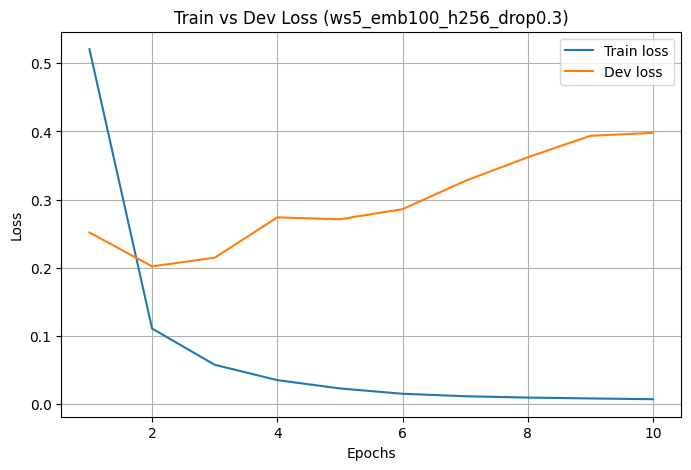

In [ ]:
# Plot train vs dev loss for the best model
plot_loss_curves(all_histories[best_config["name"]],
                 title_suffix=f"({best_config['name']})")


In [ ]:
y_train_true_m, y_train_pred_m, y_train_proba_m = predict_proba_loader(model, train_loader, device)
y_dev_true_m,   y_dev_pred_m,   y_dev_proba_m   = predict_proba_loader(model, dev_loader, device)
y_test_true_m,  y_test_pred_m,  y_test_proba_m  = predict_proba_loader(model, test_loader, device)

print("=== MLP POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (MLP)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag)
evaluate_split_full("DEV   (MLP)", y_dev_true_m,   y_dev_pred_m,   y_dev_proba_m,   idx2tag)
evaluate_split_full("TEST  (MLP)", y_test_true_m,  y_test_pred_m,  y_test_proba_m,  idx2tag)


=== MLP POS TAGGER RESULTS ===

===== TRAIN (MLP) =====
Per-tag metrics:
Tag    ADJ | P=0.9985  R=0.9902  F1=0.9943  PR-AUC=0.9999
Tag    ADP | P=0.9969  R=0.9987  F1=0.9978  PR-AUC=1.0000
Tag    ADV | P=0.9972  R=0.9818  F1=0.9895  PR-AUC=0.9994
Tag    AUX | P=0.9994  R=0.9988  F1=0.9991  PR-AUC=0.9999
Tag  CCONJ | P=0.9825  R=0.9980  F1=0.9902  PR-AUC=0.9996
Tag    DET | P=0.9906  R=0.9919  F1=0.9912  PR-AUC=0.9996
Tag   INTJ | P=0.9979  R=0.9979  F1=0.9979  PR-AUC=1.0000
Tag   NOUN | P=0.9983  R=0.9992  F1=0.9987  PR-AUC=1.0000
Tag    NUM | P=0.9972  R=0.9895  F1=0.9933  PR-AUC=0.9996
Tag   PRON | P=0.9850  R=0.9869  F1=0.9860  PR-AUC=0.9989
Tag  PROPN | P=0.9963  R=0.9995  F1=0.9979  PR-AUC=0.9999
Tag  SCONJ | P=0.9728  R=0.9911  F1=0.9819  PR-AUC=0.9981
Tag   VERB | P=0.9999  R=0.9999  F1=0.9999  PR-AUC=1.0000

Macro-averaged:
  Macro-P:       0.9933
  Macro-R:       0.9941
  Macro-F1:      0.9937
  Macro-PR-AUC:  0.9996

===== DEV   (MLP) =====
Per-tag metrics:
Tag    ADJ | P=0.9

{'Macro-P': np.float64(0.9486220437956447),
 'Macro-R': np.float64(0.9366504452480954),
 'Macro-F1': np.float64(0.9413667146934793),
 'Macro-PR-AUC': np.float64(0.9773939923472379)}

In [ ]:
# TRAIN
y_train_true_b, y_train_pred_b = baseline_predict_sents(train_sents, tag2idx)
y_train_proba_b = y_pred_to_proba(y_train_pred_b, num_tags)

# DEV
y_dev_true_b, y_dev_pred_b = baseline_predict_sents(dev_sents, tag2idx)
y_dev_proba_b = y_pred_to_proba(y_dev_pred_b, num_tags)

# TEST
y_test_true_b, y_test_pred_b = baseline_predict_sents(test_sents, tag2idx)
y_test_proba_b = y_pred_to_proba(y_test_pred_b, num_tags)

print("\n\n=== BASELINE POS TAGGER RESULTS ===")
evaluate_split_full("TRAIN (Baseline)", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag)
evaluate_split_full("DEV   (Baseline)", y_dev_true_b,   y_dev_pred_b,   y_dev_proba_b,   idx2tag)
evaluate_split_full("TEST  (Baseline)", y_test_true_b,  y_test_pred_b,  y_test_proba_b,  idx2tag)




=== BASELINE POS TAGGER RESULTS ===

===== TRAIN (Baseline) =====
Per-tag metrics:
Tag    ADJ | P=0.9845  R=0.9908  F1=0.9876  PR-AUC=0.9759
Tag    ADP | P=0.9765  R=0.9940  F1=0.9852  PR-AUC=0.9711
Tag    ADV | P=0.9726  R=0.9039  F1=0.9370  PR-AUC=0.8896
Tag    AUX | P=0.9983  R=0.9985  F1=0.9984  PR-AUC=0.9968
Tag  CCONJ | P=0.9029  R=0.9983  F1=0.9482  PR-AUC=0.9014
Tag    DET | P=0.9303  R=0.9493  F1=0.9397  PR-AUC=0.8907
Tag   INTJ | P=0.9874  R=0.9979  F1=0.9926  PR-AUC=0.9854
Tag   NOUN | P=0.9971  R=0.9971  F1=0.9971  PR-AUC=0.9947
Tag    NUM | P=0.9979  R=0.9866  F1=0.9922  PR-AUC=0.9846
Tag   PRON | P=0.9230  R=0.8992  F1=0.9110  PR-AUC=0.8406
Tag  PROPN | P=0.9942  R=0.9969  F1=0.9956  PR-AUC=0.9913
Tag  SCONJ | P=0.9085  R=0.8526  F1=0.8797  PR-AUC=0.7775
Tag   VERB | P=0.9996  R=0.9992  F1=0.9994  PR-AUC=0.9989

Macro-averaged:
  Macro-P:       0.9671
  Macro-R:       0.9665
  Macro-F1:      0.9664
  Macro-PR-AUC:  0.9384

===== DEV   (Baseline) =====
Per-tag metrics:
T

{'Macro-P': np.float64(0.9522722343525025),
 'Macro-R': np.float64(0.9196862493453299),
 'Macro-F1': np.float64(0.9324595900412523),
 'Macro-PR-AUC': np.float64(0.8811280694347892)}

In [ ]:
print("\n================= FINAL SUMMARY =================")

print("BEST CONFIG:")
for k, v in best_config.items():
    print(f"  {k}: {v}")

print(f"\nBest Dev Macro-F1 (MLP): {best_macro_f1:.4f}")

print("\nCompare MLP vs Baseline (Macro-F1):")
mlp_train_f1  = precision_recall_fscore_support(y_train_true_m, y_train_pred_m, average="macro")[2]
mlp_dev_f1    = precision_recall_fscore_support(y_dev_true_m,   y_dev_pred_m,   average="macro")[2]
mlp_test_f1   = precision_recall_fscore_support(y_test_true_m,  y_test_pred_m,  average="macro")[2]

base_train_f1 = precision_recall_fscore_support(y_train_true_b, y_train_pred_b, average="macro")[2]
base_dev_f1   = precision_recall_fscore_support(y_dev_true_b,   y_dev_pred_b,   average="macro")[2]
base_test_f1  = precision_recall_fscore_support(y_test_true_b,  y_test_pred_b,  average="macro")[2]

print(f"  TRAIN: MLP={mlp_train_f1:.4f}  | Baseline={base_train_f1:.4f}")
print(f"  DEV:   MLP={mlp_dev_f1:.4f}    | Baseline={base_dev_f1:.4f}")
print(f"  TEST:  MLP={mlp_test_f1:.4f}   | Baseline={base_test_f1:.4f}")



================= FINAL SUMMARY =================
BEST CONFIG:
  name: ws5_emb100_h256_drop0.3
  window_size: 5
  emb_dim: 100
  hidden_sizes: [256]
  dropout: 0.3
  lr: 0.001
  batch_size: 128
  num_epochs: 20

Best Dev Macro-F1 (MLP): 0.9393

Compare MLP vs Baseline (Macro-F1):
  TRAIN: MLP=0.9937  | Baseline=0.9664
  DEV:   MLP=0.9379    | Baseline=0.9211
  TEST:  MLP=0.9414   | Baseline=0.9325


In [ ]:
# === COMPARISON TABLES: BASELINE vs MLP (TRAIN / DEV / TEST) ===
import pandas as pd
from IPython.display import display

def make_results_row(model_name, y_true, y_pred, y_proba, idx2tag):
    """
    Build one row with:
      P(tag), R(tag), F1(tag), PR-AUC(tag) for each tag,
      plus Macro-P/R/F1/PR-AUC.
    Uses per_class_prf and per_class_prauc already defined above.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    prf_dict = per_class_prf(y_true, y_pred, label_order)
    ap_dict  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": model_name}
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = ap_dict[lbl]
        row[f"P({tag})"]      = float(P)
        row[f"R({tag})"]      = float(R)
        row[f"F1({tag})"]     = float(F1)
        row[f"PR-AUC({tag})"] = float(A)
        per_class_vals.append((P, R, F1, A))

    macro_P, macro_R, macro_F1, macro_A = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro_P)
    row["Macro-R"]      = float(macro_R)
    row["Macro-F1"]     = float(macro_F1)
    row["Macro-PR-AUC"] = float(macro_A)
    return row

# Tag order for columns
tags = [idx2tag[i] for i in range(len(idx2tag))]
cols = ["Model"]
for t in tags:
    cols += [f"P({t})", f"R({t})", f"F1({t})", f"PR-AUC({t})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

# --- TRAIN TABLE ---
train_rows = [
    make_results_row("Baseline", y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag),
    make_results_row("MLP",      y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag),
]
train_df = pd.DataFrame(train_rows)[cols]

# --- DEV TABLE ---
dev_rows = [
    make_results_row("Baseline", y_dev_true_b, y_dev_pred_b, y_dev_proba_b, idx2tag),
    make_results_row("MLP",      y_dev_true_m, y_dev_pred_m, y_dev_proba_m, idx2tag),
]
dev_df = pd.DataFrame(dev_rows)[cols]

# --- TEST TABLE ---
test_rows = [
    make_results_row("Baseline", y_test_true_b, y_test_pred_b, y_test_proba_b, idx2tag),
    make_results_row("MLP",      y_test_true_m, y_test_pred_m, y_test_proba_m, idx2tag),
]
test_df = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,MLP,0.9985,0.9902,0.9943,0.9999,0.9969,0.9987,0.9978,1.0000,0.9972,...,0.9819,0.9981,0.9999,0.9999,0.9999,1.0000,0.9933,0.9941,0.9937,0.9996



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,MLP,0.9430,0.7257,0.8202,0.9029,0.9892,0.9946,0.9919,0.9991,0.9743,...,0.9290,0.9730,0.8551,0.9895,0.9174,0.9857,0.9504,0.9293,0.9379,0.9756



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,MLP,0.9438,0.7819,0.8553,0.9229,0.9866,0.9955,0.9910,0.9998,0.9768,...,0.9248,0.9781,0.8576,0.9832,0.9161,0.9809,0.9486,0.9367,0.9414,0.9774


[logreg_ws5_emb100] Epoch 1/20 | train loss: 0.2932 | dev loss: 0.2174 | dev macro-F1: 0.9329
[logreg_ws5_emb100] Epoch 2/20 | train loss: 0.0353 | dev loss: 0.2115 | dev macro-F1: 0.9328
[logreg_ws5_emb100] Epoch 3/20 | train loss: 0.0187 | dev loss: 0.2199 | dev macro-F1: 0.9327
[logreg_ws5_emb100] Epoch 4/20 | train loss: 0.0127 | dev loss: 0.2306 | dev macro-F1: 0.9310
[logreg_ws5_emb100] Epoch 5/20 | train loss: 0.0097 | dev loss: 0.2402 | dev macro-F1: 0.9280
[logreg_ws5_emb100] Epoch 6/20 | train loss: 0.0078 | dev loss: 0.2540 | dev macro-F1: 0.9261
[logreg_ws5_emb100] Epoch 7/20 | train loss: 0.0067 | dev loss: 0.2730 | dev macro-F1: 0.9241

=== LOGISTIC REGRESSION (WINDOW) SUMMARY ===
Config name: logreg_ws5_emb100
Dev macro-F1: 0.9329


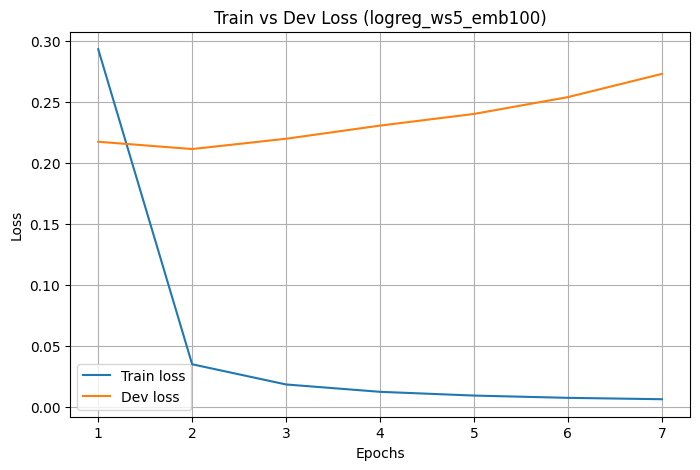

In [ ]:
# Logistic Regression window model = MLP_POS with hidden_sizes = []

logreg_config = {
    "name": "logreg_ws5_emb100",
    "window_size": 5,
    "emb_dim": 100,
    "hidden_sizes": [],   # <-- no hidden layers
    "dropout": 0.0,
    "lr": 1e-3,
    "batch_size": 128,
    "num_epochs": 20,
}

logreg_model, logreg_history, logreg_dev_macro_f1 = train_one_config(
    logreg_config,
    train_dataset=train_dataset,
    dev_dataset=dev_dataset,
    vocab_size=vocab_size,
    num_tags=num_tags,
    device=device,
)

print("\n=== LOGISTIC REGRESSION (WINDOW) SUMMARY ===")
print(f"Config name: {logreg_config['name']}")
print(f"Dev macro-F1: {logreg_dev_macro_f1:.4f}")

# loss curves for logreg
plot_loss_curves(logreg_history, title_suffix=f"({logreg_config['name']})")


In [ ]:
# Probabilities for logistic regression model on each split
y_train_true_lr, y_train_pred_lr, y_train_proba_lr = predict_proba_loader(
    logreg_model, train_loader, device
)
y_dev_true_lr,   y_dev_pred_lr,   y_dev_proba_lr   = predict_proba_loader(
    logreg_model, dev_loader, device
)
y_test_true_lr,  y_test_pred_lr,  y_test_proba_lr  = predict_proba_loader(
    logreg_model, test_loader, device
)


In [ ]:
import pandas as pd
from IPython.display import display

def make_results_row(model_name, y_true, y_pred, y_proba, idx2tag):
    """
    Build one row with:
      P(tag), R(tag), F1(tag), PR-AUC(tag) for each tag,
      plus Macro-P/R/F1/PR-AUC.
    Uses per_class_prf and per_class_prauc defined earlier.
    """
    num_tags = len(idx2tag)
    label_order = list(range(num_tags))

    prf_dict = per_class_prf(y_true, y_pred, label_order)
    ap_dict  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": model_name}
    per_class_vals = []

    for lbl in label_order:
        tag = idx2tag[lbl]
        P, R, F1 = prf_dict[lbl]
        A = ap_dict[lbl]
        row[f"P({tag})"]      = float(P)
        row[f"R({tag})"]      = float(R)
        row[f"F1({tag})"]     = float(F1)
        row[f"PR-AUC({tag})"] = float(A)
        per_class_vals.append((P, R, F1, A))

    macro_P, macro_R, macro_F1, macro_A = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro_P)
    row["Macro-R"]      = float(macro_R)
    row["Macro-F1"]     = float(macro_F1)
    row["Macro-PR-AUC"] = float(macro_A)
    return row

# Column order (per-tag 4 metrics + 4 macro metrics)
tags = [idx2tag[i] for i in range(len(idx2tag))]
cols = ["Model"]
for t in tags:
    cols += [f"P({t})", f"R({t})", f"F1({t})", f"PR-AUC({t})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

# === TRAIN TABLE ===
train_rows = [
    make_results_row("Baseline",          y_train_true_b, y_train_pred_b, y_train_proba_b, idx2tag),
    make_results_row("LogReg (window)",   y_train_true_lr, y_train_pred_lr, y_train_proba_lr, idx2tag),
    make_results_row("MLP (best config)", y_train_true_m, y_train_pred_m, y_train_proba_m, idx2tag),
]
train_df = pd.DataFrame(train_rows)[cols]

# === DEV TABLE ===
dev_rows = [
    make_results_row("Baseline",          y_dev_true_b, y_dev_pred_b, y_dev_proba_b, idx2tag),
    make_results_row("LogReg (window)",   y_dev_true_lr, y_dev_pred_lr, y_dev_proba_lr, idx2tag),
    make_results_row("MLP (best config)", y_dev_true_m, y_dev_pred_m, y_dev_proba_m, idx2tag),
]
dev_df = pd.DataFrame(dev_rows)[cols]

# === TEST TABLE ===
test_rows = [
    make_results_row("Baseline",          y_test_true_b, y_test_pred_b, y_test_proba_b, idx2tag),
    make_results_row("LogReg (window)",   y_test_true_lr, y_test_pred_lr, y_test_proba_lr, idx2tag),
    make_results_row("MLP (best config)", y_test_true_m, y_test_pred_m, y_test_proba_m, idx2tag),
]
test_df = pd.DataFrame(test_rows)[cols]

pd.options.display.float_format = "{:.4f}".format

print("=== TRAIN RESULTS ===")
display(train_df)

print("\n=== DEV RESULTS ===")
display(dev_df)

print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9845,0.9908,0.9876,0.9759,0.9765,0.9940,0.9852,0.9711,0.9726,...,0.8797,0.7775,0.9996,0.9992,0.9994,0.9989,0.9671,0.9665,0.9664,0.9384
1,LogReg (window),0.9905,0.9944,0.9924,0.9992,0.9895,0.9968,0.9931,0.9996,0.9947,...,0.9654,0.9919,0.9983,0.9998,0.9990,1.0000,0.9892,0.9863,0.9877,0.9985
2,MLP (best config),0.9985,0.9902,0.9943,0.9999,0.9969,0.9987,0.9978,1.0000,0.9972,...,0.9819,0.9981,0.9999,0.9999,0.9999,1.0000,0.9933,0.9941,0.9937,0.9996



=== DEV RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9774,0.7133,0.8247,0.7125,0.9683,0.9935,0.9807,0.9624,0.9556,...,0.8419,0.7201,0.7957,0.9989,0.8858,0.7950,0.9489,0.9039,0.9211,0.8627
1,LogReg (window),0.8987,0.7421,0.8129,0.9030,0.9818,0.9924,0.9871,0.9991,0.9748,...,0.9160,0.9659,0.8314,0.9948,0.9057,0.9859,0.9475,0.9223,0.9329,0.9757
2,MLP (best config),0.9430,0.7257,0.8202,0.9029,0.9892,0.9946,0.9919,0.9991,0.9743,...,0.9290,0.9730,0.8551,0.9895,0.9174,0.9857,0.9504,0.9293,0.9379,0.9756



=== TEST RESULTS ===


,Model,P(ADJ),R(ADJ),F1(ADJ),PR-AUC(ADJ),P(ADP),R(ADP),F1(ADP),PR-AUC(ADP),P(ADV),...,F1(SCONJ),PR-AUC(SCONJ),P(VERB),R(VERB),F1(VERB),PR-AUC(VERB),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.9730,0.7660,0.8571,0.7585,0.9723,0.9932,0.9827,0.9662,0.9746,...,0.8904,0.7953,0.7987,0.9976,0.8871,0.7972,0.9523,0.9197,0.9325,0.8811
1,LogReg (window),0.9096,0.8032,0.8531,0.9224,0.9844,0.9966,0.9905,0.9992,0.9782,...,0.9310,0.9770,0.8381,0.9944,0.9096,0.9833,0.9467,0.9278,0.9357,0.9772
2,MLP (best config),0.9438,0.7819,0.8553,0.9229,0.9866,0.9955,0.9910,0.9998,0.9768,...,0.9248,0.9781,0.8576,0.9832,0.9161,0.9809,0.9486,0.9367,0.9414,0.9774
